In [15]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [16]:
# Load dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


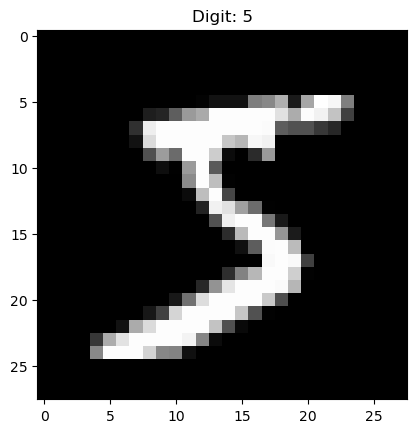

In [17]:
# Show sample image
plt.imshow(X_train[0], cmap='gray')
plt.title("Digit: " + str(y_train[0]))
plt.show()

In [18]:
# Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0

In [19]:
# Model (UPDATED)
model = keras.Sequential([
    
    keras.Input(shape=(28,28)),   # ✅ Proper input layer
    
    keras.layers.Flatten(),
    
    keras.layers.Dense(128, activation='relu'),
    
    keras.layers.Dense(64, activation='relu'),
    
    keras.layers.Dense(10, activation='softmax')
])

In [20]:
# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
# Train model
model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9278 - loss: 0.2473
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9682 - loss: 0.1041
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9779 - loss: 0.0724
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9834 - loss: 0.0533
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 9ms/step - accuracy: 0.9866 - loss: 0.0417


In [22]:
# Evaluate model
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9760 - loss: 0.0762


[0.07623781263828278, 0.9760000109672546]

In [23]:
# Predictions
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


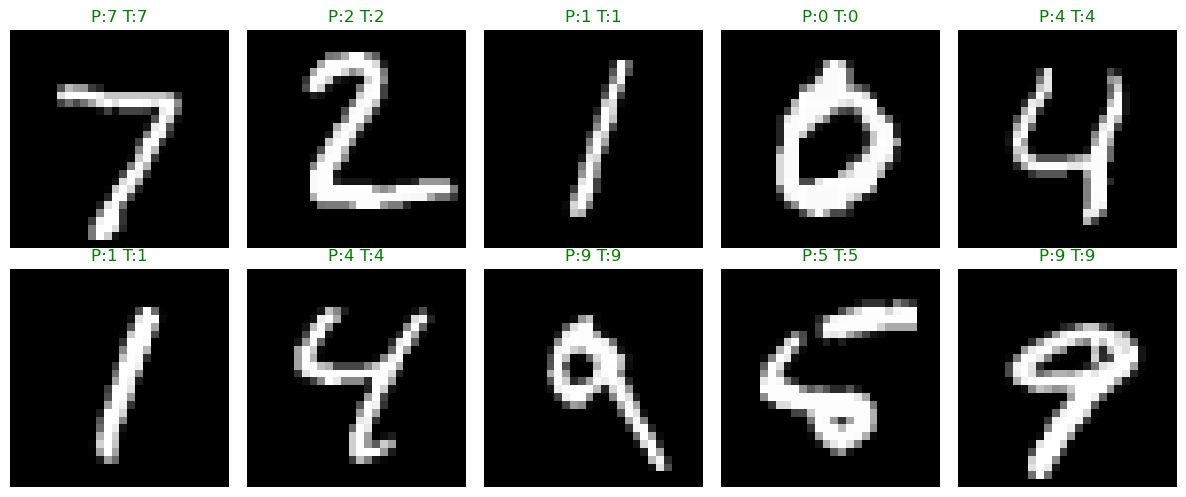

In [29]:
# Show prediction
plt.figure(figsize=(12,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i], cmap='gray')

    predicted_label = np.argmax(predictions[i])
    true_label = y_test[i]

    # Color red if prediction is wrong
    color = "green" if predicted_label == true_label else "red"

    plt.title(f"P:{predicted_label} T:{true_label}", color=color)

    plt.axis('off')

plt.tight_layout()
plt.show()